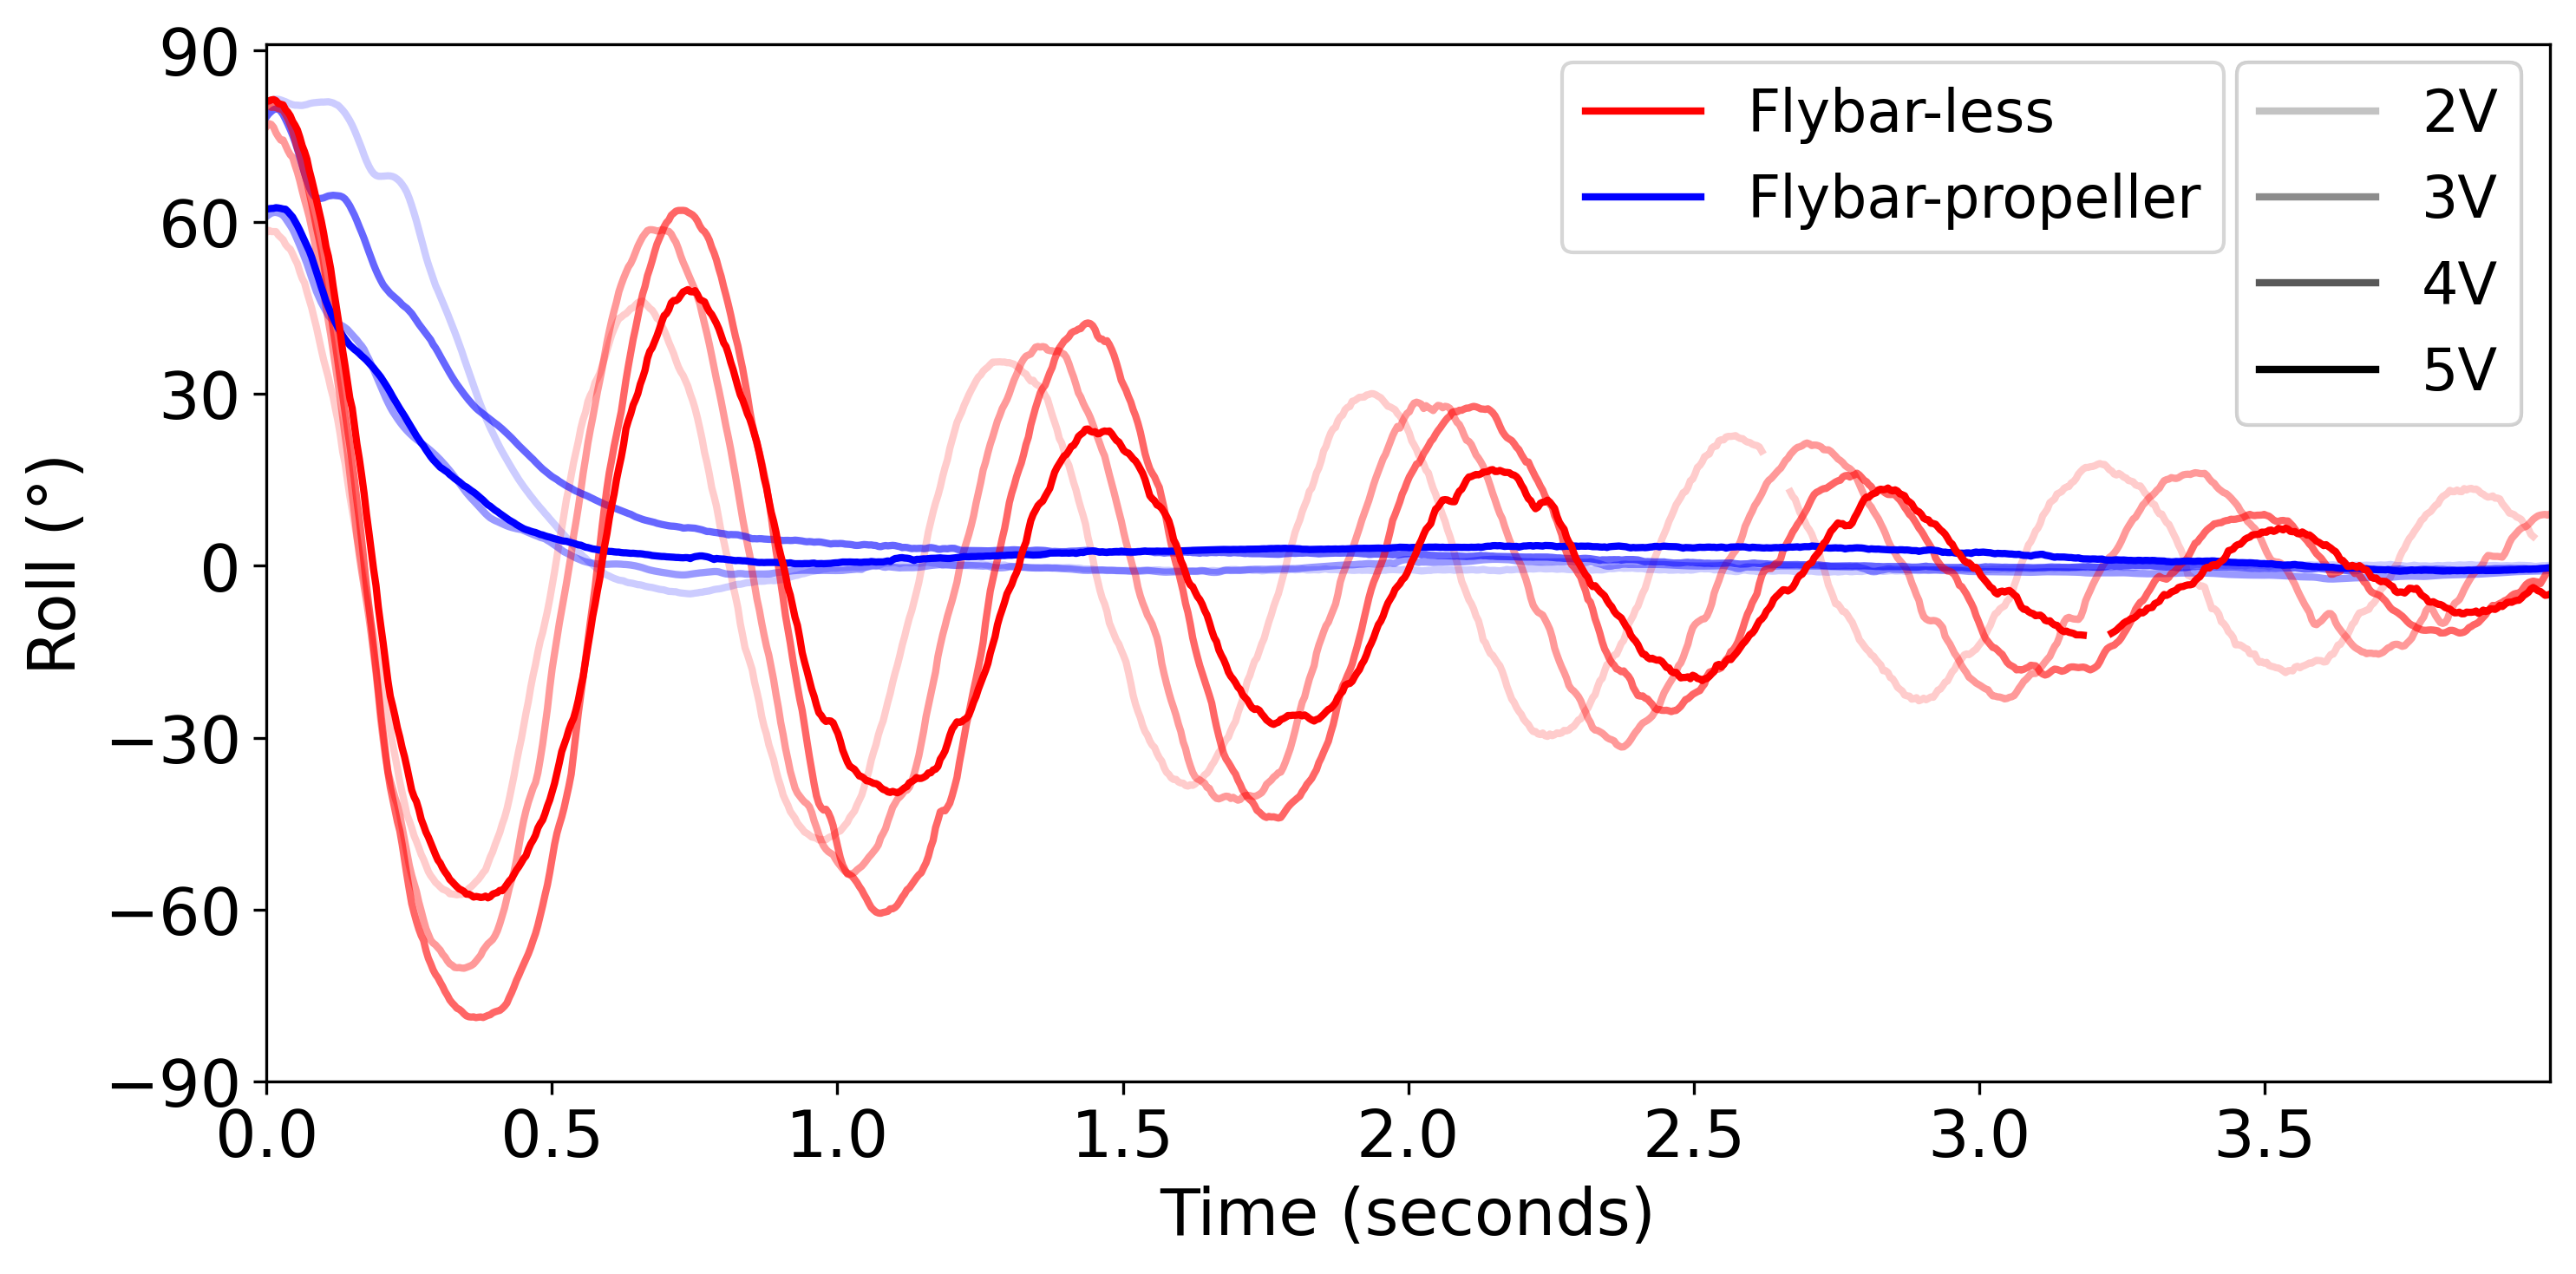

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import math
from matplotlib.lines import Line2D

# === Global Constants ===
G_PROMINENCE = 0.05
G_DISTANCE = 50
G_AXIS = 'Roll'
G_VIEW = 1000
FPS = 240

# === Adjustable Parameters per dataset ===
DATA_START_DICT = {
    "2V w/ flybar": None,
    "2V w/o flybar": 556,
    "3V w/ flybar": None,
    "3V w/o flybar": 439,
    "4V w/ flybar": None,
    "4V w/o flybar": 349,
    "5V w/ flybar": None,
    "5V w/o flybar": 305,
}

# Set the desired y-axis displacement for each dataset (in degrees)
Y_AXIS_DISPLACEMENT_DICT = {
    "2V w/ flybar": 0.5,
    "2V w/o flybar": 3.5,
    "3V w/ flybar": 1,
    "3V w/o flybar": 11.5,
    "4V w/ flybar": 0,
    "4V w/o flybar": 23.6,
    "5V w/ flybar": 1,
    "5V w/o flybar": 32.8,
}

# Set the y-axis multiplier for each dataset (default multiplier is 1)
Y_AXIS_MULTIPLIER_DICT = {
    "2V w/ flybar": 1,
    "2V w/o flybar": 4.5,
    "3V w/ flybar": 1,
    "3V w/o flybar": 5.2,
    "4V w/ flybar": 1,
    "4V w/o flybar": 6.2,
    "5V w/ flybar": 1,
    "5V w/o flybar": 5.5,
}

# === Define Transparency for Voltages ===
voltage_alphas = {
    "2V": 0.2,
    "3V": 0.4,
    "4V": 0.6,
    "5V": 1.0,
}

# === Dataset Configuration ===
datasets = [
    {"label": "2V w/ flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=0&single=true&output=csv", "voltage": "2V", "flybar": True},
    {"label": "2V w/o flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=1120735809&single=true&output=csv", "voltage": "2V", "flybar": False},
    {"label": "3V w/ flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=1919824707&single=true&output=csv", "voltage": "3V", "flybar": True},
    {"label": "3V w/o flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=2143820051&single=true&output=csv", "voltage": "3V", "flybar": False},
    {"label": "4V w/ flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=909407750&single=true&output=csv", "voltage": "4V", "flybar": True},
    {"label": "4V w/o flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=1128729220&single=true&output=csv", "voltage": "4V", "flybar": False},
    {"label": "5V w/ flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=14345894&single=true&output=csv", "voltage": "5V", "flybar": True},
    {"label": "5V w/o flybar", "url": "https://docs.google.com/spreadsheets/d/e/2PACX-1vQmvnCTtOVsd3XXFrgZJT9mmwxjr1gnNxg-d8nKewUoXEuj1pY9KKuLmS8jmmEf-4EzZ8r9Xjd_G_z1/pub?gid=2028278917&single=true&output=csv", "voltage": "5V", "flybar": False},
]

# === Quaternion to Euler conversion ===
def toDegrees(rad):
    return rad * 180 / math.pi

def euler_from_quaternion(x, y, z, w):
    t0 = +2.0 * (w * x + y * z)
    t1 = +1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(t0, t1)

    t2 = +2.0 * (w * y - z * x)
    t2 = max(min(t2, +1.0), -1.0)
    pitch = math.asin(t2)

    t3 = +2.0 * (w * z + x * y)
    t4 = +1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(t3, t4)

    return toDegrees(roll) * -1, toDegrees(pitch) * -1, toDegrees(yaw) * -1

def smooth_signal(signal, window_length=11, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

def process_euler(df, custom_start=None):
    euler_angles = df.apply(lambda row: euler_from_quaternion(row['X'], row['Y'], row['Z'], row['W']), axis=1)
    euler_df = pd.DataFrame(euler_angles.tolist(), columns=['Pitch', 'Yaw', 'Roll'])

    for axis in ['Roll', 'Yaw', 'Pitch']:
        euler_df[axis] = smooth_signal(euler_df[axis])

    peak_indices, _ = find_peaks(euler_df[G_AXIS], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)

    start_peak_idx = None
    for i in range(1, len(peak_indices)):
        if abs(euler_df[G_AXIS].iloc[peak_indices[i]] - euler_df[G_AXIS].iloc[peak_indices[i - 1]]) > 50:
            start_peak_idx = peak_indices[i - 1]
            break

    if custom_start is not None:
        start = custom_start
    else:
        start = max((start_peak_idx if start_peak_idx is not None else 0), 5)
    end = start + G_VIEW

    return euler_df.iloc[start - 5:end].reset_index(drop=True)

def trim_by_degree_change(euler_df, threshold=10):
    roll = euler_df['Roll'].values
    for i in range(1, len(roll)):
        if abs(roll[i] - roll[i - 1]) < threshold:
            return euler_df.iloc[i:].reset_index(drop=True)
    return euler_df

# === Plotting ===
plt.figure(figsize=(10, 5), dpi=300)

for data in datasets:
    # Load and process the data.
    df = pd.read_csv(data["url"])
    label = data["label"]

    custom_start = DATA_START_DICT.get(label, None)
    y_disp = Y_AXIS_DISPLACEMENT_DICT.get(label, 0)
    y_multiplier = Y_AXIS_MULTIPLIER_DICT.get(label, 1)

    euler_df = process_euler(df, custom_start=custom_start)
    euler_df_trimmed = trim_by_degree_change(euler_df)

    time_axis = np.linspace(0, len(euler_df_trimmed) / FPS, len(euler_df_trimmed))

    # Determine base color based on flybar status and set alpha based on voltage.
    base_color = 'blue' if data["flybar"] else 'red'
    alpha_value = voltage_alphas.get(data["voltage"], 0.5)

    # Apply the multiplier and displacement.
    scaled_roll = (euler_df_trimmed['Roll'] * y_multiplier) + y_disp
    plt.plot(time_axis, scaled_roll, color=base_color, alpha=alpha_value, linewidth=2)

# --- Create Custom Legends ---
# Legend for Flybar (color) - blue for with flybar, red for without flybar.
flybar_handles = [
    Line2D([0], [0], color='red', lw=2, label='Flybar-less'),
    Line2D([0], [0], color='blue', lw=2, label='Flybar-propeller')
]
flybar_legend = plt.legend(handles=flybar_handles, loc='upper right', bbox_to_anchor=(0.87, 1.01), fontsize=16)
plt.gca().add_artist(flybar_legend)

# Legend for Voltage (transparency) - using a neutral color (black) to show alpha variations.
voltage_handles = [
    Line2D([0], [0], color='black', lw=2, alpha=alpha, label=volt)
    for volt, alpha in voltage_alphas.items()
]
voltage_legend = plt.legend(handles=voltage_handles, loc='upper right', bbox_to_anchor=(1, 1.01), fontsize=16, title_fontsize=16) # title="Voltage",
plt.gca().add_artist(voltage_legend)

plt.xlabel('Time (seconds)', fontsize=18)
plt.xlim(0, 4)
plt.xticks(np.arange(0, 4, 0.5), fontsize=18)
plt.ylabel('Roll (°)', fontsize=18)
plt.ylim(-90, 91)
plt.yticks(np.arange(-90, 91, 30), fontsize=18)
#plt.grid(True)
plt.tight_layout()
plt.show()